In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import roc_curve, auc, confusion_matrix

# 데이터 로드
X = np.load('../data/X_resampled.npy')
y = np.load('../data/y_resampled.npy')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 로드
svm = joblib.load('../data/svm_model.pkl')
xgb = joblib.load('../data/xgb_model.pkl')
cat = joblib.load('../data/cat_model.pkl')
bpann = joblib.load('../data/bpann_model.pkl')

print('로드 완료!')

로드 완료!


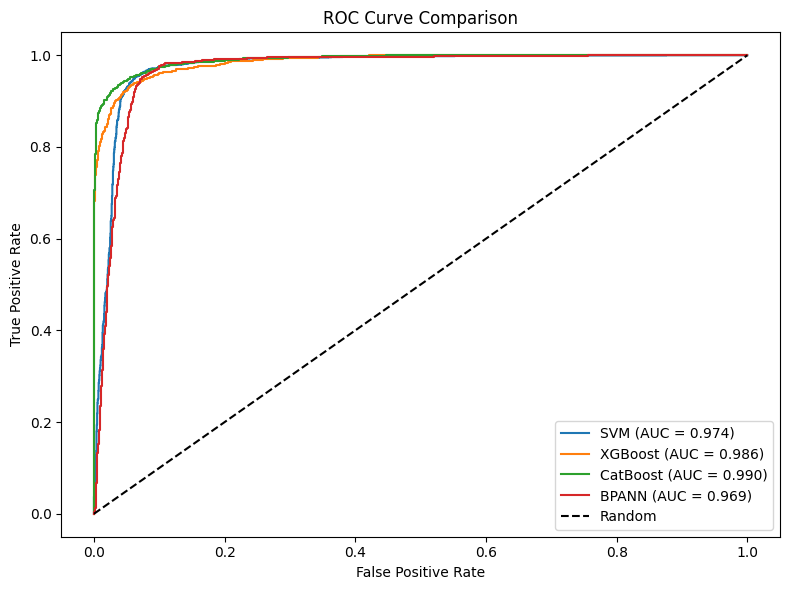

In [2]:
# ROC Curve
plt.figure(figsize=(8, 6))

models = {
    'SVM': svm,
    'XGBoost': xgb,
    'CatBoost': cat,
    'BPANN': bpann
}

for model_name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/roc_curve.png')
plt.show()

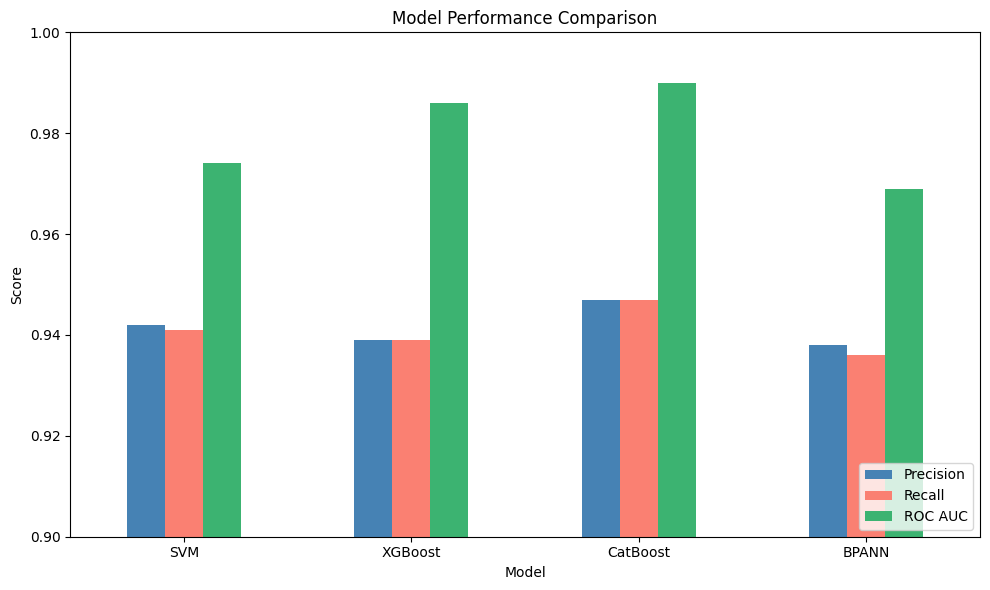

In [3]:
# 모델 성능 비교 bar chart
metrics = {
    'Model': ['SVM', 'XGBoost', 'CatBoost', 'BPANN'],
    'Precision': [0.942, 0.939, 0.947, 0.938],
    'Recall': [0.941, 0.939, 0.947, 0.936],
    'ROC AUC': [0.974, 0.986, 0.990, 0.969]
}

df_metrics = pd.DataFrame(metrics)
df_metrics.set_index('Model', inplace=True)

df_metrics.plot(kind='bar', figsize=(10, 6), ylim=(0.9, 1.0),
                color=['steelblue', 'salmon', 'mediumseagreen'])
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()

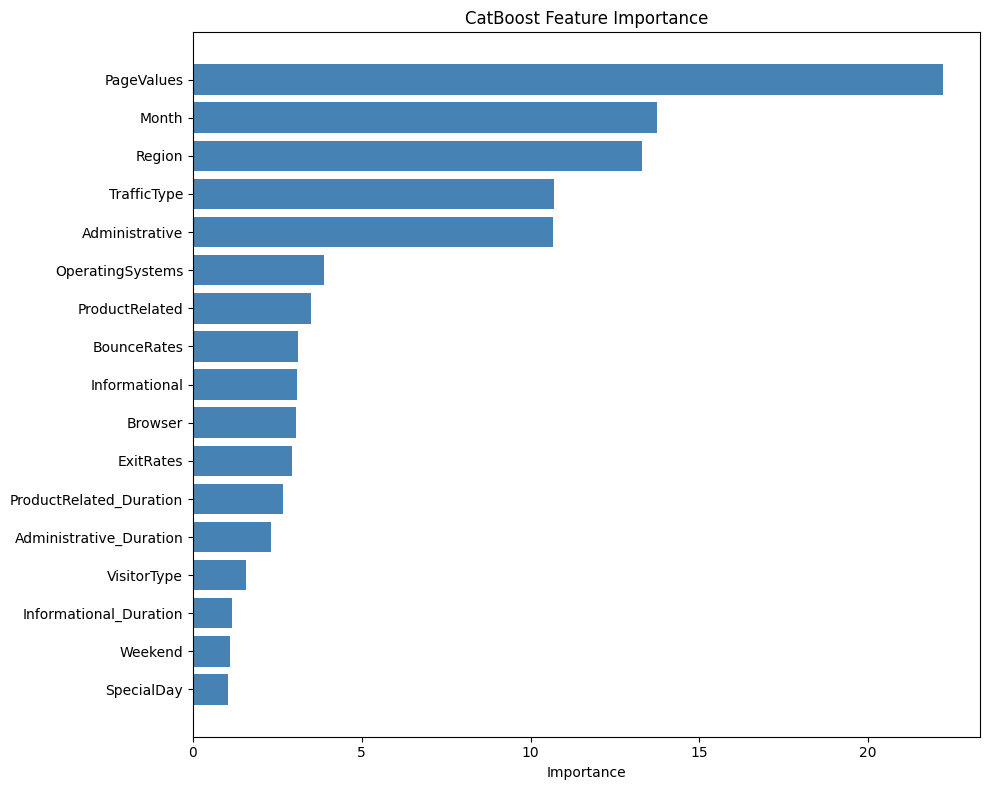

In [4]:
# Feature Importance (CatBoost)
feature_names = ['Administrative', 'Administrative_Duration', 'Informational',
                 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
                 'Month', 'OperatingSystems', 'Browser', 'Region',
                 'TrafficType', 'VisitorType', 'Weekend']

importance = cat.get_feature_importance()
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()

* 기존 논문과 특징 중요도 순위가 일부 다름<br>
=> 전처리 과정 (SMOTE 적용)의 차이에서 기인한 것으로 보임

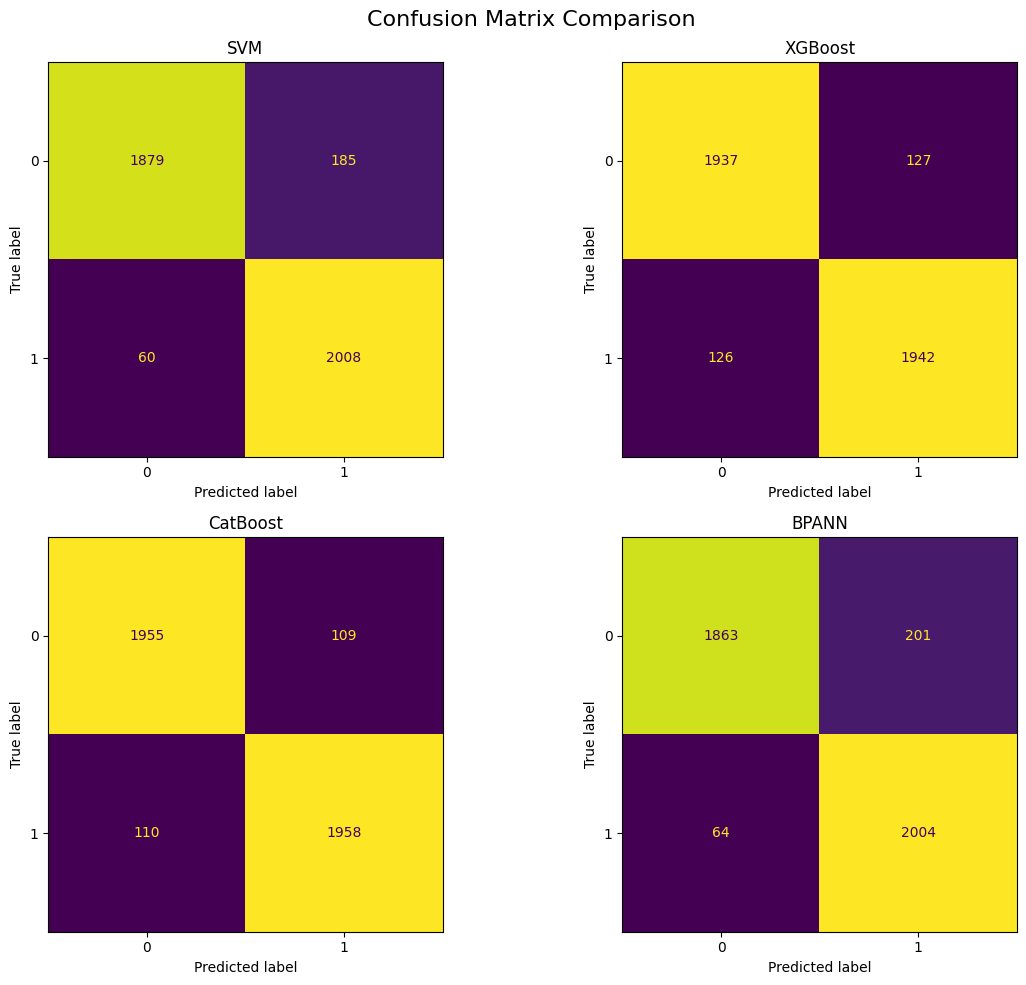

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_dict = {'SVM': svm, 'XGBoost': xgb, 'CatBoost': cat, 'BPANN': bpann}

for ax, (model_name, model) in zip(axes.flatten(), models_dict.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name}')

plt.suptitle('Confusion Matrix Comparison', fontsize=16)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png')
plt.show()

- CatBoost = FP, FN 둘 다 균형있게 낮음 -> 전반적으로 가장 우수함 <br>
- SVM, BPANN = FP가 매우 높음 -> "살 거 같다" 라고 과잉 예측하는 경향 높음 (치명적)

* BPANN의 경우, ROC 커브가 0.969로 가장 낮고 FP도 가장 높을 뿐더러 학습 시간도 가장 오래 걸림 <br>
=> 현재의 데이터셋에서 가장 비효율적 모델 

이커머스 환경에서는 부스팅 기법이 적합한 선택임